# Interplay of the material and energy transition

Electrification needs for mobility applications. In the presented perspective we try to quantify the challenges of transitioning the entire passenger vehicle fleet in Texas to electric vehicles (EVs) or hydrogen fuel cell vehicles (HFCVs)

__author__ = "Rahul Kakodkar"
__copyright__ = "Copyright 2022, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Natasha Chrisandina", "Efstratios N. Pistikopoulos"]
__license__ = "Open"
__version__ = "1.0.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"


$\textbf{Import modules}$

In [2]:
import pandas
from numpy import poly1d, polyfit
from src.energiapy.components.temporal_scale import Temporal_scale
from src.energiapy.components.resource import Resource
from src.energiapy.components.process import Process
from src.energiapy.components.material import Material
from src.energiapy.components.location import Location
from src.energiapy.components.network import Network
from src.energiapy.components.scenario import Scenario
from src.energiapy.components.transport import Transport
from src.energiapy.components.result import Result
from src.energiapy.model.formulate_milp import formulate_milp
from src.energiapy.utils.data_utils import get_data, make_henry_price_df
from src.energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from src.energiapy.plot import plot
from src.energiapy.model.pyomo_solve import solve
from src.energiapy.utils.cluster_utils import reduce_scenario, agg_hierarchial_elbow, Clustermethod
from src.energiapy.utils.data_utils import load_results
import matplotlib.pyplot as plt


In [3]:
results = {i: load_results(f"Houston_MILP_C{i+1}0.pkl") for i in range(9)}

In [12]:
carbon = [results[i].output['S_location'][('HO', 'CO2_Vent', 0)] for i in range(9)]
electrolysis = [results[i].output['P_location'][('HO', 'AKE', 0)] for i in range(9)]
smrh = [results[i].output['P_location'][('HO', 'SMRH', 0)] for i in range(9)]
smr = [results[i].output['P_location'][('HO', 'SMR', 0)] for i in range(9)]
cap_smr = [results[i].output['Cap_P'][('HO', 'SMR', 0)] for i in range(9)]
cap_smrh = [results[i].output['Cap_P'][('HO', 'SMRH', 0)] for i in range(9)]
cap_ake = [results[i].output['Cap_P'][('HO', 'AKE', 0)] for i in range(9)]

objective = [results[i].output['objective'] for i in range(9)]

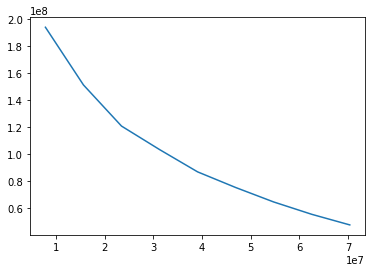

In [5]:
plt.plot(carbon, objective)


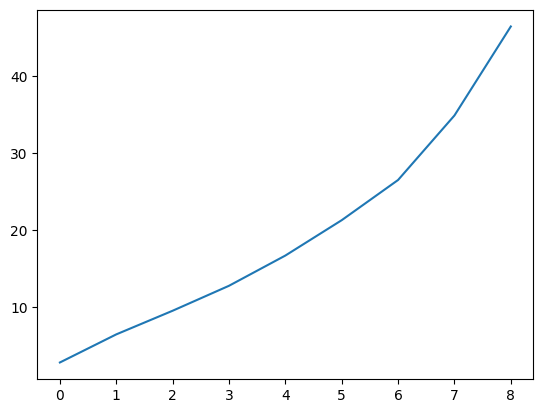

In [14]:
# plt.plot(smrh)
# plt.plot(smr)
plt.plot(cap_ake)



$\textit{Scheduling results}$

Can be generated at the index of the variable for any component at any location

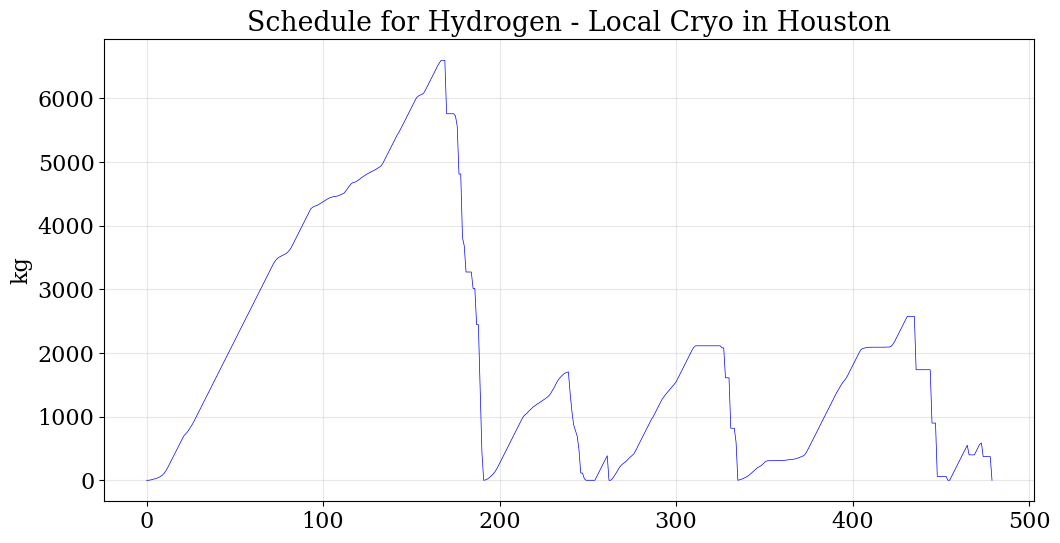

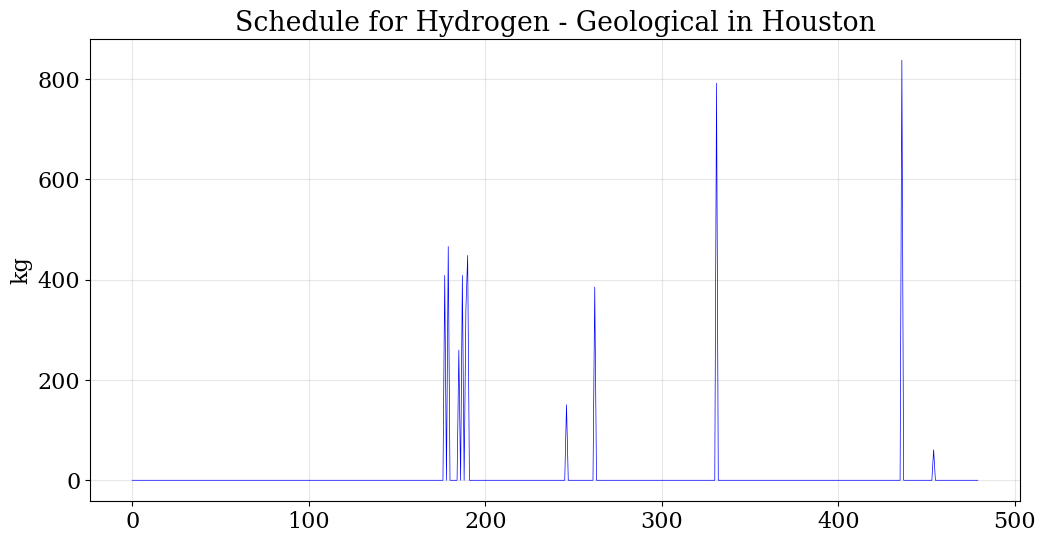

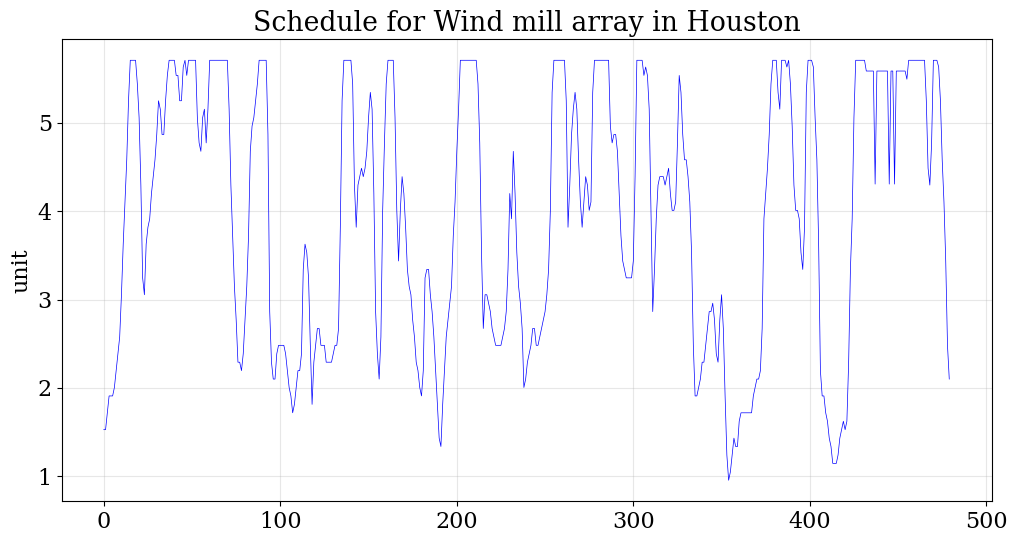

In [15]:
plot.schedule(results=results[0], y_axis='Inv',
               component='H2_C', location='HO')

plot.schedule(results=results[0], y_axis='Inv',
               component='H2_L', location='HO')

plot.schedule(results=results[0], y_axis='P',
               component='WF', location='HO')

# graph.schedule(results=results_sl, y_axis='P',
#                component='WF', location='HO')

# graph.schedule(results=results_sl, y_axis='P',
#                component='AKE', location='HO')



In [ ]:
 if heuristic == True:
        # if last iteration was infeasible... diversify [toll is lower as well]
        if objective[iter_ - 1] == 10**10:
            toll = 0.5  # tolerance to be used
            for prod in prod_list:  # problem is combinatorally divided for each product
                # print(prod)
                # ordered sources based on production potential
                prod_pot_ord = [source for source in list(
                    prod_pot_ord_dict[prod].keys())]
                # fix sources [source_x = 1] for top two quartiles
                prod_pot_fix = prod_pot_ord[:int(round(len(prod_pot_ord)/2))]

                # print('prod_pot_ord')
                # print(prod_pot_ord)
                # print('prod_pot_fix')
                # print(prod_pot_fix)

                for source in range(n_sources):
                    # print('source ' + str(source))
                    if source in prod_pot_fix:  # source in 2nd quartile essentially
                        # print('fix 1')
                        # print(source)
                        # generate a random number
                        random_n = random.uniform(0, 1)
                        # if number less than tolerance affix source [lower tolerance helps diversify]
                        if random_n < toll:
                            m.source_x[prod, source].fix(1.0)
                        else:
                            m.source_x[prod, source].fix(0.0)

                        # now affix sinks with the 2nd quartile of distances
                        sinks_distance_ord = [sink for sink in list(
                            distances_ord_dict[source].keys())]
                        sinks_distance_fix = sinks_distance_ord[:int(
                            round(len(sinks_distance_ord)/2))]
                        fix = 1.0  # affix transportation linkages to 1 only if source exists, and within 2nd distance quartile

                    else:
                        # print('fix 0')
                        # print(source)
                        random_n = random.uniform(0, 1)
                        if random_n < toll:  # for the rest randomly affix some.
                            m.source_x[prod, source].fix(0.0)
                        else:
                            m.source_x[prod, source].fix(1.0)

                        sinks_distance_ord = [sink for sink in list(
                            distances_ord_dict[source].keys())]
                        sinks_distance_fix = sinks_distance_ord
                        fix = 0.0  # affix transportation linkages to 0 if source does not exist
                    # print('sinks_distance_ord')
                    # print(sinks_distance_ord)
                    # print('sinks_distance_fix')
                    # print(sinks_distance_fix)
                    for sink in range(n_sinks):
                        if sink in sinks_distance_fix:
                            # print('fix ' + str(fix))
                            # print(sink)
                            m.linkage_x[prod, sink, source].fix(fix)
                        # else:
                            # print('fix 0')
                            # print(sink)
                            # m.linkage_x[prod, sink, source].fix(0.0)

        # if last iteration was not infeasible... intensify [toll is higher as well]
        else:
            toll = 0.8  # higher tolerance, accept more solutions
            # first iter is set to MIP solution [can be changed, need to generalize].
            if iter_ == 1:
                # so this is the first heuristic iteration
                for prod in prod_list:
                    # print(prod)

                    prod_pot_ord = [source for source in list(
                        prod_pot_ord_dict[prod].keys())]  # order sources by prod pot
                    # affix within 2nd quartile
                    prod_pot_fix = prod_pot_ord[:int(
                        round(len(prod_pot_ord)/2))]

                    # print('prod_pot_ord')
                    # print(prod_pot_ord)
                    # print('prod_pot_fix')
                    # print(prod_pot_fix)
                    for source in range(n_sources):
                        # print('source ' + str(source))
                        if source in prod_pot_fix:
                            # print('fix 1')
                            # print(source)

                            # located facilities greedily
                            m.source_x[prod, source].fix(1.0)
                            sinks_distance_ord = [sink for sink in list(
                                distances_ord_dict[source].keys())]
                            sinks_distance_fix = sinks_distance_ord[:int(
                                round(len(sinks_distance_ord)/2))]
                            fix = 1.0

                        else:
                            # print('fix 0')
                            # print(source)

                            # do not locate facilities here
                            m.source_x[prod, source].fix(0.0)
                            sinks_distance_ord = [sink for sink in list(
                                distances_ord_dict[source].keys())]
                            sinks_distance_fix = sinks_distance_ord
                            fix = 0.0
                        # print('sinks_distance_ord')
                        # print(sinks_distance_ord)
                        # print('sinks_distance_fix')
                        # print(sinks_distance_fix)
                        for sink in range(n_sinks):
                            if sink in sinks_distance_fix:
                                # print('fix ' + str(fix))
                                # print(sink)
                                # set all linkages to 1 from affixed sources to sinks
                                m.linkage_x[prod, sink, source].fix(fix)
                            # else:
                                # print('fix 0')
                                # print(sink)
                                # m.linkage_x[prod, sink, source].fix(0.0)

            else:
                if (iter_ > 3):
                    # if solution has not improved
                    if (objective[iter_-1] < 1.005*objective[iter_ - 2]):

                        # print(objective[iter_-1], objective[iter_-2])
                        print('===============================================')
                        for prod, source in product(prod_list, range(n_sources)):
                            # if source was already affixed to 1 and needs to be reassigned
                            if source_re_dict[source][prod] == 1:
                                # randomly shuffle the affixed
                                random_n = random.uniform(0, 1)
                                if random_n < toll:
                                    m.source_x[prod, source].fix(1.0)
                                else:
                                    m.source_x[prod, source].fix(0.0)

                            else:  # if source was already affixed to 0 and needs to be reassigned
                                random_n = random.uniform(
                                    0, 1)  # randomly shuffle
                                if random_n < toll:
                                    m.source_x[prod, source].fix(1.0)
                                else:
                                    m.source_x[prod, source].fix(0.0)

                            for sink in range(n_sinks):
                                # if linkage was already affixed to 1 and needs to be reassigned
                                if linkage_re_dict[source][sink][prod] == 1:
                                    random_n = random.uniform(0, 1)
                                    if random_n < toll:
                                        m.linkage_x[prod, sink,
                                                    source].fix(1.0)
                                    else:
                                        m.linkage_x[prod, sink,
                                                    source].fix(0.0)

                                else:  # if linkage was already affixed to 0 and needs to be reassigned
                                    random_n = random.uniform(0, 1)
                                    if random_n < toll:
                                        m.linkage_x[prod, sink,
                                                    source].fix(1.0)
                                    else:
                                        m.linkage_x[prod, sink,
                                                    source].fix(0.0)

                else:  # if solution is not too bad, start stitching the solution
                    # note that sources and linkages are cycled with the intension of being affixed
                    # not utilized facilities and linakges are set to 0
                    # this helps improve the solution by avoiding uncessary facilities, linkages
                    # All binaries are still affixed!
                    print('++++++++++++++++++++++++++++++++++++++++++++++++++++++')

                    for prod, source in product(prod_list, range(n_sources)):
                        # keep the affixed sources
                        if source_re_dict[source][prod] == 1:
                            m.source_x[prod, source].fix(1.0)
                        else:
                            m.source_x[prod, source].fix(0.0)

                        for sink in range(n_sinks):  # keep the affixed linkages
                            if linkage_re_dict[source][sink][prod] == 1:
                                m.linkage_x[prod, sink, source].fix(1.0)
                            else:
                                m.linkage_x[prod, sink, source].fix(0.0)